# FinBERT-VAE-GAN Prediction Pipeline

This notebook implements section 4.2 from the economic-signal PDF and the GAN/attention mechanism reference paper.

Architecture mapping:

- FinBERT converts optional news text into daily positive/negative/neutral sentiment features.
- VAE denoises flattened technical-indicator lag features and extracts latent representations.
- GAN regularizes the latent space with generator/discriminator training.
- An attention-gated predictor combines latent market features and sentiment features for close-price forecasting.

If no `NEWS_CSV` is provided, the pipeline uses neutral sentiment features so the price pipeline still runs reproducibly.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import pandas as pd
from IPython.display import Image, display

SRC_DIR = Path.cwd() / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from benchmark_utils import INDEX_TICKERS
from plot_results import plot_price_predictions, plot_tensor_surface

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)


## Configuration

In [2]:
START = "2010-01-01"
END = "2026-06-01"
TRAIN_END = "2025-12-31"
TEST_START = "2026-01-01"
TEST_END = "2026-05-31"

LOOKBACK = 30
HORIZON = 1
TOP_K = 16
EPOCHS = 80

RUN_TRAINING = True
NEWS_CSV = None  # Optional CSV with columns: date,text
FINBERT_MODEL = "ProsusAI/finbert"

OUTPUT_DIR = Path(f"outputs_finbert_vae_gan_h{HORIZON}")
PLOTS_DIR = Path(f"plots_finbert_vae_gan_h{HORIZON}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)


## Train FinBERT-VAE-GAN

In [3]:
if RUN_TRAINING:
    cmd = [
        sys.executable, str(SRC_DIR / "finbert_vae_gan.py"),
        "--start", START, "--end", END,
        "--train-end", TRAIN_END, "--test-start", TEST_START, "--test-end", TEST_END,
        "--lookback", str(LOOKBACK), "--horizon", str(HORIZON), "--top-k", str(TOP_K),
        "--epochs", str(EPOCHS), "--output-dir", str(OUTPUT_DIR),
        "--finbert-model", FINBERT_MODEL,
    ]
    if NEWS_CSV:
        cmd.extend(["--news-csv", str(NEWS_CSV)])
    print(" ".join(cmd))
    completed = subprocess.run(cmd, check=True, text=True, capture_output=True)
    print(completed.stdout)
    if completed.stderr:
        print(completed.stderr)

summary = pd.read_csv(OUTPUT_DIR / "benchmark_summary.csv")
summary


c:\Users\zoufuc\AppData\Local\Programs\Python\Python311\python.exe c:\Users\zoufuc\Desktop\Time-Series-Data-Prediction\src\finbert_vae_gan.py --start 2010-01-01 --end 2026-06-01 --train-end 2025-12-31 --test-start 2026-01-01 --test-end 2026-05-31 --lookback 30 --horizon 1 --top-k 16 --epochs 80 --output-dir outputs_finbert_vae_gan_h1 --finbert-model ProsusAI/finbert
Running FinBERT-VAE-GAN Nasdaq (^IXIC)...
Nasdaq: RMSE=264.04, MAE=211.31, MAPE=0.90%
Running FinBERT-VAE-GAN SP500 (^GSPC)...
SP500: RMSE=57.98, MAE=44.69, MAPE=0.65%
Running FinBERT-VAE-GAN SOX (^SOX)...
SOX: RMSE=232.81, MAE=180.22, MAPE=1.98%
Saved outputs to C:\Users\zoufuc\Desktop\Time-Series-Data-Prediction\outputs_finbert_vae_gan_h1



,index,ticker,rmse,mae,mape_pct,naive_rmse,naive_mae,rmse_vs_naive_pct,mae_vs_naive_pct,direction_accuracy_pct,samples,train_samples,model,features,sentiment_source,final_vae_loss,final_train_loss,final_val_loss
0,Nasdaq,^IXIC,264.044373,211.306442,0.903657,265.655273,212.978867,0.606388,0.785254,48.039216,102,3935,FinBERT-VAE-GAN,"['Low', 'High', 'Open', 'MA_5', 'EMA_12', 'MA_...",neutral,0.041037,0.359714,0.361093
1,SP500,^GSPC,57.977127,44.685909,0.647673,58.252670,44.949280,0.473014,0.585928,58.823529,102,3935,FinBERT-VAE-GAN,"['Low', 'High', 'Open', 'MA_5', 'EMA_12', 'MA_...",neutral,0.043476,0.346186,0.283187
2,SOX,^SOX,232.811661,180.224411,1.983728,232.848175,180.839233,0.015682,0.339983,54.901961,102,3935,FinBERT-VAE-GAN,"['Low', 'High', 'Open', 'MA_5', 'EMA_12', 'MA_...",neutral,0.037983,0.351219,0.491190


## Benchmark Summary

In [4]:
metric_cols = [
    "index", "ticker", "model", "samples", "train_samples", "rmse", "mae", "mape_pct",
    "naive_rmse", "naive_mae", "rmse_vs_naive_pct", "mae_vs_naive_pct",
    "direction_accuracy_pct", "sentiment_source", "final_vae_loss", "final_train_loss", "final_val_loss",
]
summary[metric_cols]


,index,ticker,model,samples,train_samples,rmse,mae,mape_pct,naive_rmse,naive_mae,rmse_vs_naive_pct,mae_vs_naive_pct,direction_accuracy_pct,sentiment_source,final_vae_loss,final_train_loss,final_val_loss
0,Nasdaq,^IXIC,FinBERT-VAE-GAN,102,3935,264.044373,211.306442,0.903657,265.655273,212.978867,0.606388,0.785254,48.039216,neutral,0.041037,0.359714,0.361093
1,SP500,^GSPC,FinBERT-VAE-GAN,102,3935,57.977127,44.685909,0.647673,58.252670,44.949280,0.473014,0.585928,58.823529,neutral,0.043476,0.346186,0.283187
2,SOX,^SOX,FinBERT-VAE-GAN,102,3935,232.811661,180.224411,1.983728,232.848175,180.839233,0.015682,0.339983,54.901961,neutral,0.037983,0.351219,0.491190


## Feature Ranking

In [5]:
feature_ic = {
    index_name: pd.read_csv(OUTPUT_DIR / f"{index_name}_feature_ic.csv").head(TOP_K)
    for index_name in summary["index"]
}
feature_ic["Nasdaq"]


,feature,ic,abs_ic
0,Low,0.999640,0.999640
1,High,0.999632,0.999632
2,Open,0.999549,0.999549
3,MA_5,0.999406,0.999406
4,EMA_12,0.999116,0.999116
5,MA_10,0.999029,0.999029
6,EMA_26,0.998329,0.998329
7,MA_20,0.998256,0.998256
8,MA_60,0.995249,0.995249
9,Volume,0.882157,0.882157


## Generate Plots

In [6]:
for index_name in summary["index"]:
    plot_tensor_surface(
        index_name=index_name,
        raw_path=OUTPUT_DIR / f"{index_name}_raw.csv",
        feature_ic_path=OUTPUT_DIR / f"{index_name}_feature_ic.csv",
        output_path=PLOTS_DIR / f"{index_name}_tensor_3d.png",
        lookback=LOOKBACK, horizon=HORIZON, top_k=TOP_K,
        train_end=TRAIN_END, test_start=TEST_START, test_end=TEST_END,
    )
    plot_price_predictions(
        index_name=index_name,
        prediction_path=OUTPUT_DIR / f"{index_name}_predictions.csv",
        output_path=PLOTS_DIR / f"{index_name}_price_prediction.png",
    )
print(f"Saved plots to {PLOTS_DIR.resolve()}")


Saved plots to C:\Users\zoufuc\Desktop\Time-Series-Data-Prediction\plots_finbert_vae_gan_h1


## Display Example Plot

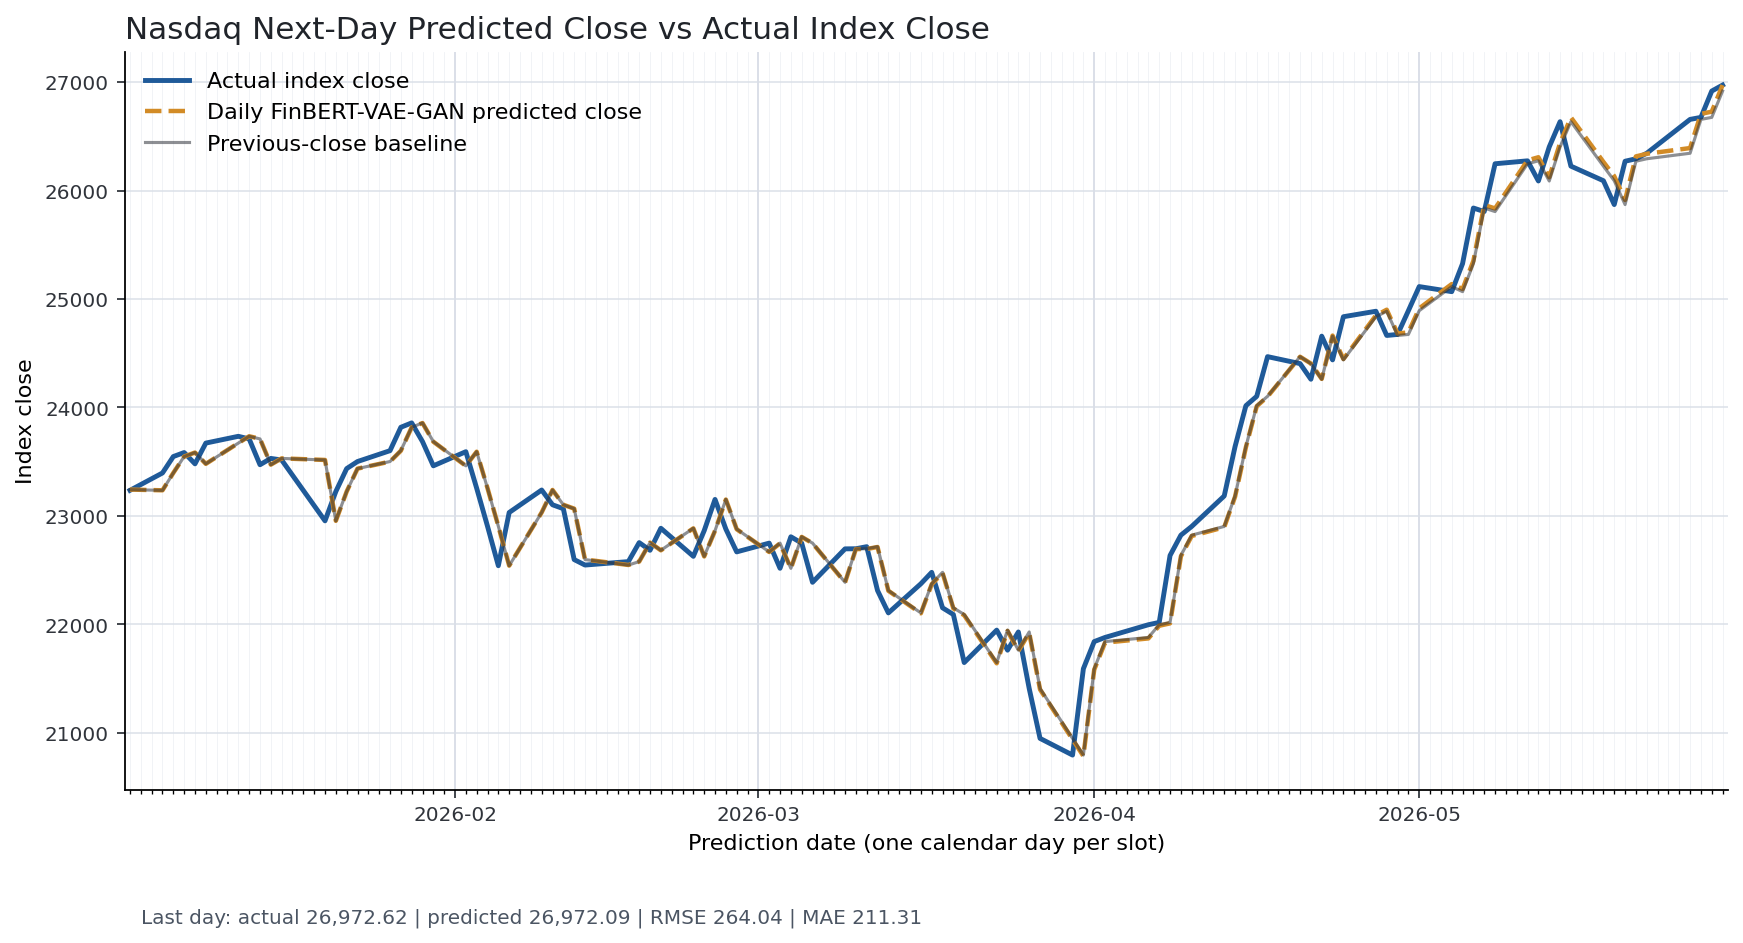

In [7]:
example_plot = PLOTS_DIR / "Nasdaq_price_prediction.png"
if example_plot.exists():
    display(Image(filename=str(example_plot)))
else:
    print(f"Plot not found: {example_plot}")
